# W4D2 — Fine-Tuning ResNet-18 on Flowers — Lab

**Week 4 · Day 2 · CNNs & Model Fine-Tuning** · Lab

Yesterday you trained a small CNN from scratch on 320 photos and fought it every step of the way:
augmentation, batch norm, dropout, a validation curve that would not climb. Today you stop starting
from scratch. You borrow **ResNet-18** — the architecture lineage from this morning, already trained
on 1.28 million ImageNet photos — **freeze** all 11 million of its parameters, and train only a new
last layer of 5,130 numbers on 126 photos of flowers.

Three things, in order:

- **Data from Kaggle.** One line of `kagglehub` downloads a public dataset into a cache — the way
  most of your capstone data will arrive.
- **Your own `Dataset` class.** These photos have no folder per class; their labels sit in a CSV. So
  `ImageFolder` cannot read them, and you write the three methods it would have written for you.
- **A frozen backbone and a new head.** Ten flower species, about twenty photos each, and a network
  that has never seen a phlox. It still gets 38 of 42 test photos right.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٤ · اليوم ٢ — الضبط الدقيق لـResNet-18 على الأزهار

**الأسبوع الرابع · اليوم الثاني · الشبكات الالتفافية وضبط النماذج** · معمل

بالأمس درّبتَ شبكة التفافية صغيرة من الصفر على ٣٢٠ صورة وصارعتها في كل خطوة: التكثير، وتطبيع
الدفعات، والإسقاط العشوائي، ومنحنى تحقّق لا يريد أن يصعد. واليوم تتوقّف عن البدء من الصفر. تستعير
**ResNet-18** — من سلالة المعماريات التي رأيتها هذا الصباح، وقد دُرِّبت مسبقًا على ١٫٢٨ مليون صورة من
ImageNet — و**تُجمّد** معاملاتها الأحد عشر مليونًا كلها، ولا تُدرّب إلا طبقة أخيرة جديدة من ٥٬١٣٠ عددًا على
١٢٦ صورة أزهار.

ثلاثة أشياء بالترتيب:

- **بيانات من Kaggle.** سطر واحد من `kagglehub` يُنزّل مجموعة بيانات عامّة إلى ذاكرة تخزين مؤقّت — وهي
  الطريقة التي ستصلك بها معظم بيانات مشروع التخرّج.
- **صنف `Dataset` من كتابتك.** هذه الصور ليس لكل فئة منها مجلّد؛ بل تصنيفاتها في ملف CSV. فلا يستطيع
  `ImageFolder` قراءتها، وتكتب أنت الدوال الثلاث التي كان سيكتبها لك.
- **عمود فقري مُجمَّد ورأس جديد.** عشرة أنواع من الأزهار، نحو عشرين صورة لكلٍّ منها، وشبكة لم ترَ زهرة
  فلوكس قطّ. ومع ذلك تُصيب ٣٨ من ٤٢ صورة اختبار.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Download a public Kaggle dataset with `kagglehub`, pin its version, and say where the files went.
- Write a `torch.utils.data.Dataset` subclass — `__init__`, `__len__`, `__getitem__` — for images
  whose labels live in a CSV, and say why it reads each image only when asked.
- Load a pretrained `resnet18` and name its parts: the convolutional backbone, the global average pool
  and the 1,000-class `fc` head.
- Freeze the backbone with `requires_grad = False`, replace the head, and show that only 5,130 of
  11.2 million parameters train.
- Explain why a frozen backbone also needs its batch-norm layers kept in evaluation mode, and prove
  the backbone came out of training unchanged.
- Score the test set once, read the confusion matrix, and look at the photos it got wrong.

<div dir="rtl" align="right">

## أهداف التعلّم

في نهاية هذا المعمل تستطيع:

- أن تُنزّل مجموعة بيانات عامّة من Kaggle بـ`kagglehub`، وتُثبّت إصدارها، وتقول أين ذهبت الملفات.
- أن تكتب صنفًا فرعيًا من `torch.utils.data.Dataset` — `__init__` و`__len__` و`__getitem__` — لصور
  تصنيفاتها في ملف CSV، وتقول لماذا لا يقرأ الصورة إلا حين تُطلب.
- أن تُحمّل `resnet18` مُدرَّبة مسبقًا وتسمّي أجزاءها: العمود الفقري الالتفافي، والتجميع المتوسّط الشامل،
  ورأس `fc` ذا الألف فئة.
- أن تُجمّد العمود الفقري بـ`requires_grad = False`، وتستبدل الرأس، وتُبيّن أن ٥٬١٣٠ معاملًا فقط من ١١٫٢
  مليونًا هي التي تتدرّب.
- أن تشرح لماذا يحتاج العمود الفقري المُجمَّد أيضًا إلى إبقاء طبقات تطبيع الدفعات فيه في وضع التقييم،
  وتُثبت أنه خرج من التدريب بلا تغيير.
- أن تُقيّم مجموعة الاختبار مرّة واحدة، وتقرأ مصفوفة الالتباس، وتنظر إلى الصور التي أخطأ فيها.

</div>

## About the data

**Dataset:** [`olgabelitskaya/flower-color-images`](https://www.kaggle.com/datasets/olgabelitskaya/flower-color-images),
version 7, on Kaggle — a 52 MB archive. The author made it from her own flower photographs and
published it "for absolutely free usage by any site visitor".

Today you use its first variant, `flower_images/`: **210 PNG photos, 128×128, of 10 species** —
phlox, rose, calendula, iris, shasta daisy, bellflower, viola, rudbeckia, peony and aquilegia — with
between 15 and 26 photos each. The labels are not in the folder names. They are in
`flower_labels.csv`, one row per file: `file,label`, where `label` is an integer 0–9. The names that go
with the integers are on the dataset's Kaggle page, not in the archive, so the setup writes them out
as `FLOWER_NAMES`.

The archive also holds a second variant, `flowers/`: 603 photos of 20 species with the label in the
first two characters of each file name. That is Section 3.

**The known problems with it.**

- **It is tiny.** About 21 photos a species, and after the split 126 for training. A network trained
  from scratch on that would memorise it; that is the whole case for borrowing a pretrained one.
- **The test set is 42 photos**, so one photo is 2.4 points of accuracy. Read the third decimal place
  as noise.
- **The photos are 128×128 and ResNet-18 was trained at 224×224.** The transform scales them up. The
  pixels it invents carry no new detail, and a flower with fine structure at 128 px is blurrier at 224.
- **One file is 208×208, not 128×128.** The `Resize` in the transform makes that harmless — which is
  one reason every image goes through the same resize, even when "they are all the same size".

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** [`olgabelitskaya/flower-color-images`](https://www.kaggle.com/datasets/olgabelitskaya/flower-color-images)،
الإصدار ٧، على Kaggle — أرشيف بحجم ٥٢ ميغابايت. صنعتها صاحبتها من صورها الخاصّة للأزهار، ونشرتها
«للاستعمال المجّاني التامّ لأي زائر للموقع».

وتستعمل اليوم نسختها الأولى، `flower_images/`: **٢١٠ صور PNG بحجم ١٢٨×١٢٨ لعشرة أنواع** — الفلوكس،
والورد، والآذريون (كالندولا)، والسوسن (آيريس)، وأقحوان شاستا، والجريسية، والبنفسج، والرودبيكيا، والفاوانيا،
والأكويليجيا — بين ١٥ و٢٦ صورة لكلٍّ منها. والتصنيفات ليست في أسماء المجلّدات، بل في `flower_labels.csv`،
صف لكل ملف: `file,label`، و`label` عدد صحيح من ٠ إلى ٩. والأسماء المقابلة للأعداد في صفحة المجموعة على
Kaggle لا في الأرشيف، ولذلك يكتبها الإعداد في `FLOWER_NAMES`.

ويحوي الأرشيف أيضًا نسخة ثانية، `flowers/`: ٦٠٣ صور لعشرين نوعًا، والتصنيف في أول حرفين من اسم كل ملف.
وتلك هي مادّة القسم الثالث.

**المشكلات المعروفة فيها.**

- **صغيرة جدًا.** نحو ٢١ صورة للنوع، وبعد التقسيم ١٢٦ للتدريب. والشبكة المُدرَّبة عليها من الصفر تحفظها
  عن ظهر قلب؛ وهذه هي الحجّة كلها لاستعارة شبكة مُدرَّبة مسبقًا.
- **مجموعة الاختبار ٤٢ صورة**، فالصورة الواحدة ٢٫٤ نقطة من الدقّة. فاقرأ المنزلة العشرية الثالثة ضجيجًا.
- **الصور ١٢٨×١٢٨ وResNet-18 دُرِّبت على ٢٢٤×٢٢٤.** فيُكبّرها التحويل. والبكسلات التي يخترعها لا تحمل
  تفصيلًا جديدًا، والزهرة ذات البنية الدقيقة عند ١٢٨ بكسل تصير أكثر ضبابية عند ٢٢٤.
- **ملف واحد حجمه ٢٠٨×٢٠٨ لا ١٢٨×١٢٨.** و`Resize` في التحويل يجعل ذلك بلا ضرر — وهذا أحد أسباب أن تمرّ
  كل صورة بالتحجيم نفسه، حتى حين «تكون كلها بالحجم نفسه».

</div>

## Setup

Run this first. It installs `kagglehub` if it is missing, imports everything, and fixes the seed.

<div dir="rtl" align="right">

## الإعداد

شغّل هذه الخلية أولًا. تُثبّت `kagglehub` إن لم تكن موجودة، وتستورد كل شيء، وتُثبّت البذرة.

</div>

In [1]:
# === AIEP portable setup — works locally (conda) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, device, versions
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("kagglehub", "matplotlib", "scikit-learn", "pyarrow")   # ← only this lab's extra packages
seed_everything(42)                                             # course-wide seed

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

SEED = 42
EPOCHS = 15             # measured: about 2.5 s an epoch on a laptop CPU, test accuracy 0.905
BATCH_SIZE = 16
LEARNING_RATE = 1e-3

# Label i is FLOWER_NAMES[i]. The archive holds only the integers; the names are on the Kaggle page.
FLOWER_NAMES = ["phlox", "rose", "calendula", "iris", "shasta daisy",
                "bellflower", "viola", "rudbeckia", "peony", "aquilegia"]

print(versions(), "| device:", device(), "(this lab trains on the CPU — it is small enough)")

📦 Installing: kagglehub
python 3.14.6 | numpy 2.4.6 | pandas 3.0.3 | scikit-learn 1.9.0 | torch 2.14.0+cpu | device: cpu (this lab trains on the CPU — it is small enough)


## Section 1 — Warm-up: getting data from Kaggle, and looking at it  (≈25 min)

Everything in this section already works. Read it, run it, and look.

### The download, line by line

Kaggle hosts tens of thousands of public datasets. Each has a **handle**, the part of its URL after
`kaggle.com/datasets/`: here `olgabelitskaya/flower-color-images`, which is *owner / dataset*.
`kagglehub` is Kaggle's official Python package for fetching one:

```python
import kagglehub
path = kagglehub.dataset_download("olgabelitskaya/flower-color-images/versions/7")
```

What that one call does:

1. **Downloads the archive** (52 MB here) the first time, and **unzips it into a cache** — by
   default `~/.cache/kagglehub/datasets/<owner>/<dataset>/versions/<n>/` in your home folder, or
   `/root/.cache/...` on Colab.
2. **Returns the path** to the unzipped folder, as a string. Everything after this line is ordinary
   file handling: `Path(path) / "flower_images"`.
3. **On every later run, downloads nothing.** It sees the files in the cache and returns the same path
   at once. So the cell is safe to re-run, and the notebook works offline after the first time.

**`/versions/7` pins the version.** Without it you get whatever the latest version is on the day you
run it, and an author who adds photos next month silently changes your results. A pinned version is
the dataset equivalent of `requirements.lock`.

**No account is needed for a public dataset.** Private datasets and competition data need an API
token: on kaggle.com, *Settings → API → Create New Token* downloads `kaggle.json`; put it in
`~/.kaggle/kaggle.json`, or set the `KAGGLE_USERNAME` and `KAGGLE_KEY` environment variables. Never
commit that file — it is a password.

**Two other routes you will see.** The `kaggle` command-line tool does the same with a token:
`kaggle datasets download -d olgabelitskaya/flower-color-images --unzip -p data/`. And the website's
*Download* button gives you a zip by hand — which works once, on one machine, and is exactly what the
two lines above replace.

**On Windows, if the unzip fails** with `FileNotFoundError` on a long file name, the cache path is
over Windows' 260-character limit. Set a short cache folder *before* importing `kagglehub` —
`os.environ["KAGGLEHUB_CACHE"] = "C:/kh"` — and run the cell again.

<div dir="rtl" align="right">

## القسم الأول — الإحماء: جلب البيانات من Kaggle والنظر إليها (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا. اقرأه، وشغّله، وانظر.

### التنزيل سطرًا سطرًا

يستضيف Kaggle عشرات الآلاف من مجموعات البيانات العامّة. ولكلٍّ منها **مُعرِّف** (handle)، وهو الجزء من
رابطها بعد `kaggle.com/datasets/`: هنا `olgabelitskaya/flower-color-images`، أي *المالك / المجموعة*.
و`kagglehub` هي حزمة Python الرسمية من Kaggle لجلب واحدة منها:

```python
import kagglehub
path = kagglehub.dataset_download("olgabelitskaya/flower-color-images/versions/7")
```

ما يفعله هذا النداء الواحد:

١. **يُنزّل الأرشيف** (٥٢ ميغابايت هنا) في المرّة الأولى، و**يفكّ ضغطه في ذاكرة تخزين مؤقّت** — افتراضيًا
   `~/.cache/kagglehub/datasets/<owner>/<dataset>/versions/<n>/` في مجلّدك الشخصي، أو `/root/.cache/...`
   على Colab.
٢. **يُرجع المسار** إلى المجلّد المفكوك نصًّا. وكل ما بعد هذا السطر تعامل عادي مع الملفات:
   `Path(path) / "flower_images"`.
٣. **لا يُنزّل شيئًا في كل تشغيل لاحق.** يرى الملفات في الذاكرة المؤقّتة فيُرجع المسار نفسه فورًا. فالخلية
   آمنة لإعادة التشغيل، والدفتر يعمل بلا اتّصال بعد المرّة الأولى.

**`/versions/7` تُثبّت الإصدار.** فبدونها تحصل على أحدث إصدار يوم تُشغّلها، والمؤلّفة التي تُضيف صورًا الشهر
القادم تُغيّر نتائجك بصمت. والإصدار المُثبَّت هو نظير `requirements.lock` في البيانات.

**لا حاجة إلى حساب لمجموعة عامّة.** أمّا المجموعات الخاصّة وبيانات المسابقات فتحتاج إلى رمز API: في
kaggle.com، *Settings → API → Create New Token* يُنزّل `kaggle.json`؛ ضعه في `~/.kaggle/kaggle.json`، أو
اضبط متغيّرَي البيئة `KAGGLE_USERNAME` و`KAGGLE_KEY`. ولا تودِع ذلك الملف في git أبدًا — فهو كلمة سرّ.

**طريقان آخران ستراهما.** أداة سطر الأوامر `kaggle` تفعل الشيء نفسه برمز:
`kaggle datasets download -d olgabelitskaya/flower-color-images --unzip -p data/`. وزرّ *Download* في
الموقع يُعطيك ملف zip باليد — وهذا يعمل مرّة واحدة على جهاز واحد، وهو بالضبط ما يحلّ محلّه السطران أعلاه.

**على Windows، إن فشل فكّ الضغط** بخطأ `FileNotFoundError` على اسم ملف طويل، فمسار الذاكرة المؤقّتة تجاوز
حدّ Windows البالغ ٢٦٠ حرفًا. اضبط مجلّدًا قصيرًا *قبل* استيراد `kagglehub` —
`os.environ["KAGGLEHUB_CACHE"] = "C:/kh"` — وأعد تشغيل الخلية.

</div>

In [2]:
import kagglehub

KAGGLE_HANDLE = "olgabelitskaya/flower-color-images/versions/7"   # owner / dataset / pinned version

DATA_ROOT = Path(kagglehub.dataset_download(KAGGLE_HANDLE))       # downloads once, then reads the cache
IMAGE_DIR = DATA_ROOT / "flower_images" / "flower_images"
LABELS_CSV = IMAGE_DIR / "flower_labels.csv"

print(f"kagglehub returned: {DATA_ROOT}\n")
for item in sorted(DATA_ROOT.iterdir()):
    print(f"  {item.name}{'/' if item.is_dir() else ''}")
print(f"\n{IMAGE_DIR.relative_to(DATA_ROOT)}/ holds {len(list(IMAGE_DIR.glob('*.png')))} PNG files "
      f"and {LABELS_CSV.name}")

100%|██████████| 50.1M/50.1M [00:04<00:00, 13.0MB/s]

Extracting files...


kagglehub returned: C:\Users\pc\.cache\kagglehub\datasets\olgabelitskaya\flower-color-images\versions\7

  flower_images/
  FlowerColorImages.h5
  flowers/

flower_images\flower_images/ holds 210 PNG files and flower_labels.csv


### Look at the data before you model it

The CSV first, because it *is* the labelling: two columns, one row per photo. Then the class counts —
the majority-class baseline is the number any model has to beat — and one photo of each species.

<div dir="rtl" align="right">

### انظر إلى البيانات قبل أن تُنمذجها

ملف CSV أولًا، لأنه **هو** التصنيف: عمودان، وصف لكل صورة. ثم أعداد الفئات — فخطّ الأساس للفئة الأكبر هو
الرقم الذي يجب أن يتجاوزه أي نموذج — ثم صورة واحدة من كل نوع.

</div>

       file  label
0  0001.png      0
1  0002.png      0
2  0003.png      2
3  0004.png      0
4  0005.png      0 

210 rows, columns ['file', 'label'], labels 0 to 9
        species  photos
0         phlox      21
1          rose      20
2     calendula      19
3          iris      22
4  shasta daisy      21
5    bellflower      25
6         viola      23
7     rudbeckia      15
8         peony      26
9     aquilegia      18

majority-class baseline: 0.124 — always guessing 'peony'
image sizes: {(128, 128): np.int64(209), (208, 208): np.int64(1)}


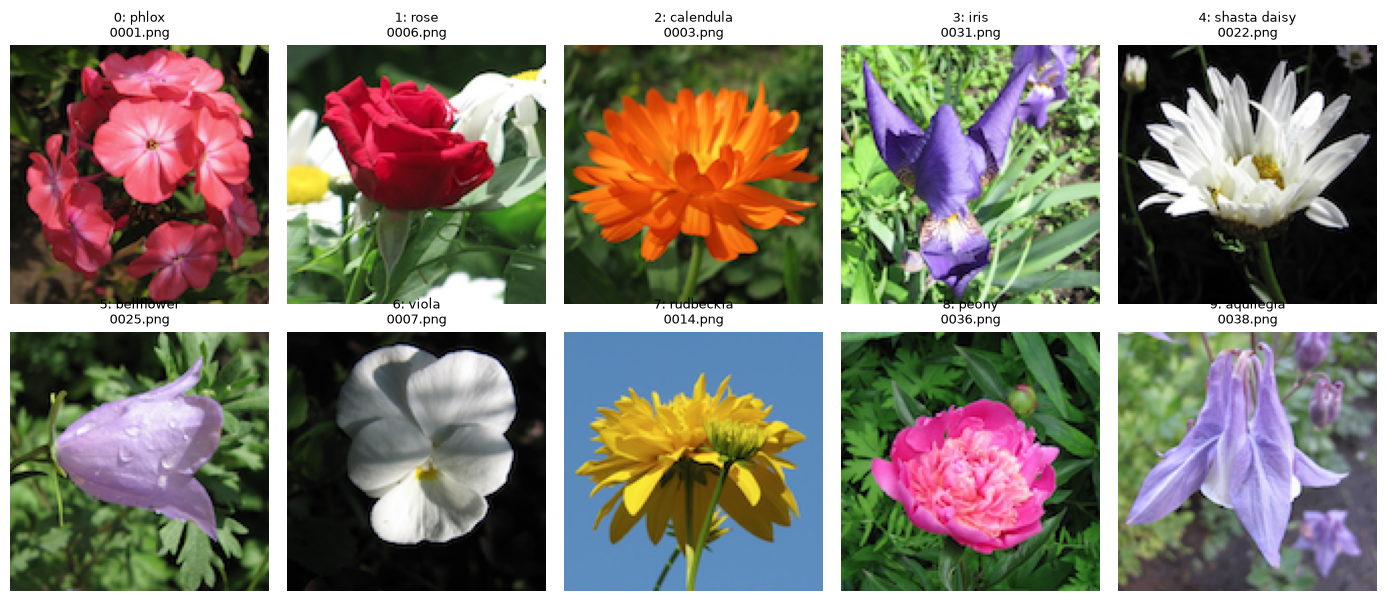

In [3]:
labels = pd.read_csv(LABELS_CSV)
print(labels.head(), "\n")
print(f"{len(labels)} rows, columns {list(labels.columns)}, labels {labels['label'].min()} to "
      f"{labels['label'].max()}")

counts = labels["label"].value_counts().sort_index()
print(pd.DataFrame({"species": FLOWER_NAMES, "photos": counts.to_numpy()}).to_string())
print(f"\nmajority-class baseline: {counts.max() / len(labels):.3f} — always guessing "
      f"'{FLOWER_NAMES[counts.idxmax()]}'")

sizes = pd.Series([Image.open(IMAGE_DIR / f).size for f in labels["file"]]).value_counts()
print("image sizes:", dict(sizes))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for label, ax in enumerate(axes.ravel()):
    file = labels.loc[labels["label"] == label, "file"].iloc[0]
    ax.imshow(Image.open(IMAGE_DIR / file))
    ax.set_title(f"{label}: {FLOWER_NAMES[label]}\n{file}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Section 2 — Core: six tasks  (≈60 min)

1. `FlowerDataset` — a `Dataset` class over the CSV.
2. Transforms, a stratified split, and three `DataLoader`s.
3. Meet ResNet-18: its parts, its 11.7 million parameters, and what it thinks an iris is.
4. Freeze the backbone, replace the head, and count what still trains.
5. Train the head.
6. Score the test set once, and look at what it got wrong.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: ست مهام (نحو ٦٠ دقيقة)

١. `FlowerDataset` — صنف `Dataset` فوق ملف CSV.
٢. التحويلات، وتقسيم طبقي، وثلاثة `DataLoader`.
٣. تعرّف إلى ResNet-18: أجزاؤها، ومعاملاتها الـ١١٫٧ مليونًا، وما تظنّه عن زهرة السوسن.
٤. جمّد العمود الفقري، واستبدل الرأس، وعُدّ ما يزال يتدرّب.
٥. درّب الرأس.
٦. قيّم مجموعة الاختبار مرّة واحدة، وانظر إلى ما أخطأ فيه.

</div>

### Task 2.1 — a `Dataset` class over the labels table

On W3D4 you wrapped two tensors in a `TensorDataset`, and yesterday `ImageFolder` read a folder per
class. Both are `Dataset`s, and both stop working here: the images are not tensors yet, and there is
no folder per class. So you write the class yourself. It takes the **labels table** you just looked
at — any table with a `file` and a `label` column — plus the folder and a transform. PyTorch asks for
three methods, and `__init__` is already written:

| method | what it does |
|---|---|
| `__init__(self, table, image_dir, transform=None)` | keeps the table, the folder and the transform — nothing else |
| `__len__(self)` | the number of images: one per row of the table |
| `__getitem__(self, index)` | row `index` of the table → open that file → apply the transform → return `(image, label)` |

Three things to notice:

- **The images are read in `__getitem__`, one at a time, only when asked.** For 210 small photos
  loading them all up front would also work; for 200,000 it would not fit in memory. This is the
  pattern that scales.
- **The transform runs inside `__getitem__`**, so a random augmentation draws a fresh version every
  time an image is read — every epoch — as yesterday.
- **It takes a table, not the CSV file.** So any slice of the table is a dataset of its own: in task
  2.2 you split the table into three and get your training, validation and test sets with one line
  each.

Use `self.table.iloc[index]` to get a row: it counts positions 0, 1, 2 … whatever the row labels
are. Open the image with `.convert("RGB")` — a PNG can carry a fourth, transparency, channel, and
ResNet-18 wants exactly three — and return the label as a plain `int`.

<div dir="rtl" align="right">

### المهمة ٢٫١ — صنف `Dataset` فوق جدول التصنيفات

في الأسبوع ٣ اليوم ٤ لففتَ موتّرين في `TensorDataset`، وبالأمس قرأ `ImageFolder` مجلّدًا لكل فئة. وكلاهما
`Dataset`، وكلاهما يتوقّف عن العمل هنا: فالصور ليست موتّرات بعد، ولا يوجد مجلّد لكل فئة. فتكتب الصنف بنفسك.
وهو يأخذ **جدول التصنيفات** الذي نظرت إليه للتوّ — أي جدول فيه عمودا `file` و`label` — مع المجلّد والتحويل.
وتطلب PyTorch ثلاث دوال، و`__init__` مكتوبة لك:

| الدالة | ما تفعله |
|---|---|
| `__init__(self, table, image_dir, transform=None)` | تحفظ الجدول والمجلّد والتحويل — لا شيء غير ذلك |
| `__len__(self)` | عدد الصور: صورة لكل صف في الجدول |
| `__getitem__(self, index)` | الصف `index` من الجدول ← افتح ذلك الملف ← طبّق التحويل ← أرجِع `(image, label)` |

ثلاثة أشياء تستحقّ الانتباه:

- **تُقرأ الصور في `__getitem__` واحدة واحدة، حين تُطلب فقط.** ولـ٢١٠ صور صغيرة يصلح تحميلها كلها مسبقًا
  أيضًا؛ أمّا لـ٢٠٠٬٠٠٠ صورة فلن تتّسع لها الذاكرة. وهذا النمط هو الذي يتوسّع.
- **يعمل التحويل داخل `__getitem__`**، فيسحب التكثير العشوائي نسخة جديدة في كل مرّة تُقرأ فيها الصورة — في
  كل حقبة — كما بالأمس.
- **يأخذ جدولًا لا ملف CSV.** فكل شريحة من الجدول مجموعة بيانات قائمة بذاتها: وفي المهمة ٢٫٢ تقسم الجدول
  ثلاثة أقسام فتحصل على مجموعات التدريب والتحقّق والاختبار بسطر واحد لكلٍّ منها.

استعمل `self.table.iloc[index]` لتأخذ صفًّا: فهي تعدّ المواضع ٠ و١ و٢ … أيًّا كانت تسميات الصفوف. وافتح
الصورة بـ`.convert("RGB")` — فقد تحمل صورة PNG قناة رابعة للشفافية، وResNet-18 تريد ثلاث قنوات بالضبط —
وأرجِع التصنيف `int` عاديًا.

</div>

In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) __len__: the number of rows in self.table.
# 2) __getitem__: row = self.table.iloc[index]; open self.image_dir / row["file"] with
#    Image.open(...).convert("RGB"); apply self.transform only if it is not None.
# 3) Return the image and int(row["label"]).
# Search: "pytorch custom Dataset __getitem__ __len__ pandas dataframe images"
# https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
#
# ١) `__len__`: عدد صفوف `self.table`.
# ٢) `__getitem__`: `row = self.table.iloc[index]`؛ وافتح `self.image_dir / row["file"]` بـ
#    `Image.open(...).convert("RGB")`؛ وطبّق `self.transform` فقط إن لم يكن `None`.
# ٣) أرجِع الصورة و`int(row["label"])`.
# ابحث عن: "pytorch custom Dataset __getitem__ __len__ pandas dataframe images"
# ────────────────────────────────────────────────────────────────────

class FlowerDataset(Dataset):
    """One item per row of a table with columns `file` and `label`."""
    def __init__(self, table, image_dir, transform=None):
        self.table = table
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]
        image = Image.open(self.image_dir / row["file"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row["label"])


dataset = FlowerDataset(labels, IMAGE_DIR)        # the whole table, no transform yet
image, label = dataset[0]
print(f"len(dataset) = {len(dataset)}")
print(f"dataset[0] -> {type(image).__name__}, size {image.size}, mode {image.mode!r}, "
      f"label {label} = {FLOWER_NAMES[label]}")
print(f"the table's first row: {labels.iloc[0]['file']} -> {labels.iloc[0]['label']}")
DATASET_LABELS = [dataset[i][1] for i in range(len(dataset))]
print(f"labels from the class match the table row for row: "
      f"{DATASET_LABELS == labels['label'].tolist()}")

len(dataset) = 210
dataset[0] -> Image, size (128, 128), mode 'RGB', label 0 = phlox
the table's first row: 0001.png -> 0
labels from the class match the table row for row: True


### Task 2.2 — split the table, then one dataset per split

Three steps, and the first two are written for you.

**1. Split the table.** `train_test_split` accepts a DataFrame and hands back DataFrames. Called twice
it gives 60 / 20 / 20: 126 training rows, 42 validation, 42 test. `stratify=` keeps each species'
share the same in all three.

**2. The transforms.** A pretrained network expects its inputs prepared exactly the way its training
images were: 224×224, three channels, normalised with the **ImageNet** mean and standard deviation.
The weights object carries those numbers, so you never type them. Two pipelines, as yesterday:

- `EVAL_TRANSFORM` — `Resize((224, 224))` → `ToTensor()` → `Normalize(MEAN, STD)`. Nothing random.
- `TRAIN_TRANSFORM` — the same, but starting with `RandomResizedCrop(224, scale=(0.7, 1.0))` and
  `RandomHorizontalFlip()`: a flower photographed a little closer, or mirrored, is the same species.

**3. Your part: three datasets and three loaders.** One `FlowerDataset` per table — the training table
with `TRAIN_TRANSFORM`, the other two with `EVAL_TRANSFORM` — and a `DataLoader` around each. Shuffle
the training loader only.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — اقسم الجدول، ثم مجموعة بيانات لكل قسم

ثلاث خطوات، والأوليان مكتوبتان لك.

**١. اقسم الجدول.** تقبل `train_test_split` جدول `DataFrame` وتُرجع جداول. ومناداتها مرّتين تُعطي ٦٠ / ٢٠ /
٢٠: ١٢٦ صفًّا للتدريب و٤٢ للتحقّق و٤٢ للاختبار. و`stratify=` تُبقي حصّة كل نوع واحدة في الثلاثة.

**٢. التحويلات.** الشبكة المُدرَّبة مسبقًا تتوقّع مُدخلاتها مُعدَّة تمامًا كما أُعدّت صور تدريبها: ٢٢٤×٢٢٤، وثلاث
قنوات، ومُطبَّعة بمتوسّط **ImageNet** وانحرافه المعياري. وكائن الأوزان يحمل هذين العددين فلا تكتبهما أبدًا.
وسلسلتان كالأمس:

- `EVAL_TRANSFORM` — `Resize((224, 224))` ← `ToTensor()` ← `Normalize(MEAN, STD)`. لا شيء عشوائي.
- `TRAIN_TRANSFORM` — الشيء نفسه، لكنه يبدأ بـ`RandomResizedCrop(224, scale=(0.7, 1.0))` و
  `RandomHorizontalFlip()`: فالزهرة المُصوَّرة أقرب قليلًا، أو المعكوسة، من النوع نفسه.

**٣. دورك: ثلاث مجموعات وثلاثة مُحمِّلات.** `FlowerDataset` لكل جدول — جدول التدريب مع `TRAIN_TRANSFORM`،
والآخران مع `EVAL_TRANSFORM` — و`DataLoader` حول كلٍّ منها. واخلط مُحمِّل التدريب وحده.

</div>

In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) train_set = FlowerDataset(train_df, IMAGE_DIR, TRAIN_TRANSFORM). The validation and
#    test sets use their own tables and EVAL_TRANSFORM.
# 2) DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True). Validation and test:
#    batch_size=64 and no shuffle, so their order matches val_df and test_df.
# 3) One training batch should be (16, 3, 224, 224) images and (16,) labels.
# Search: "pytorch DataLoader custom Dataset shuffle batch_size"
# https://pytorch.org/docs/stable/data.html
#
# ١) `train_set = FlowerDataset(train_df, IMAGE_DIR, TRAIN_TRANSFORM)`. ومجموعتا التحقّق
#    والاختبار تستعملان جدولَيهما و`EVAL_TRANSFORM`.
# ٢) `DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)`. والتحقّق والاختبار:
#    `batch_size=64` بلا خلط، ليطابق ترتيبهما `val_df` و`test_df`.
# ٣) يجب أن تكون دفعة تدريب واحدة صورًا (16, 3, 224, 224) وتصنيفات (16,).
# ابحث عن: "pytorch DataLoader custom Dataset shuffle batch_size"
# ────────────────────────────────────────────────────────────────────

train_df, rest_df = train_test_split(labels, test_size=0.4, stratify=labels["label"],
                                     random_state=SEED)
val_df, test_df = train_test_split(rest_df, test_size=0.5, stratify=rest_df["label"],
                                   random_state=SEED)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)} rows")

WEIGHTS = models.ResNet18_Weights.IMAGENET1K_V1
MEAN, STD = WEIGHTS.transforms().mean, WEIGHTS.transforms().std
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# الحل: ثلاث مجموعات
train_set = FlowerDataset(train_df, IMAGE_DIR, TRAIN_TRANSFORM)
val_set = FlowerDataset(val_df, IMAGE_DIR, EVAL_TRANSFORM)
test_set = FlowerDataset(test_df, IMAGE_DIR, EVAL_TRANSFORM)

# الحل: ثلاثة مُحمِّلات (الخلط للتدريب وحده)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"one training batch: images {tuple(xb.shape)} {xb.dtype}, labels {tuple(yb.shape)} "
      f"{yb.dtype}")

train 126 | val 42 | test 42 rows
one training batch: images (16, 3, 224, 224) torch.float32, labels (16,) torch.int64


### Task 2.3 — meet ResNet-18

Nothing to write here: load the network, read it, and ask it a question.

`models.resnet18(weights=WEIGHTS)` builds the architecture and loads the weights it learned on
ImageNet — 1.28 million photos in 1,000 classes. The first call downloads them (about 45 MB) into
`~/.cache/torch/`; later calls read the cache. Its parts, in the order a photo meets them:

- **`conv1`, `bn1`, `relu`, `maxpool`** — a 7×7 convolution with stride 2 and a pool: 224×224 becomes
  56×56 straight away.
- **`layer1` … `layer4`** — four stages of *residual blocks*, the idea from this morning's lineage:
  each block learns a correction that is added to its input, which is what lets a network this deep
  train at all. Channels go 64 → 128 → 256 → 512 while the map shrinks to 7×7.
- **`avgpool`** — `AdaptiveAvgPool2d((1, 1))`: each of the 512 maps averaged to one number.
- **`fc`** — `Linear(512, 1000)`: one score per ImageNet class.

Everything up to `avgpool` is the **backbone**: it turns a photo into 512 numbers that describe it.
`fc` is the **head**: it turns those 512 numbers into an answer. Today you keep the backbone and throw
the head away.

The cell also shows the ImageNet head an iris. ImageNet has no "iris" class, so watch what it reaches
for instead. On the machine this notebook was written on, its three top guesses were all birds —
*European gallinule*, *jay*, *little blue heron* — every one of them purple or blue. It sees the colour
and has no flower to put it on. That is not a failure of the backbone: the 512 numbers under that head
still describe the photo well. The head was just asked the wrong question, and that is the one part
you are about to replace.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — تعرّف إلى ResNet-18

لا شيء تكتبه هنا: حمّل الشبكة، واقرأها، واسألها سؤالًا.

`models.resnet18(weights=WEIGHTS)` تبني المعمارية وتُحمّل الأوزان التي تعلّمتها على ImageNet — ١٫٢٨ مليون
صورة في ألف فئة. ويُنزّلها النداء الأول (نحو ٤٥ ميغابايت) إلى `~/.cache/torch/`، وتقرأ النداءات اللاحقة
الذاكرة المؤقّتة. وأجزاؤها بالترتيب الذي تلقاها به الصورة:

- **`conv1` و`bn1` و`relu` و`maxpool`** — التفاف ٧×٧ بخطوة ٢ ثم تجميع: فتصير ٢٢٤×٢٢٤ ٥٦×٥٦ مباشرة.
- **`layer1` … `layer4`** — أربع مراحل من *الكتل المتبقّية* (residual blocks)، فكرة سلالة هذا الصباح: كل
  كتلة تتعلّم تصحيحًا يُضاف إلى دخلها، وهذا ما يسمح لشبكة بهذا العمق أن تتدرّب أصلًا. وتنتقل القنوات
  ٦٤ ← ١٢٨ ← ٢٥٦ ← ٥١٢ بينما تتقلّص الخريطة إلى ٧×٧.
- **`avgpool`** — `AdaptiveAvgPool2d((1, 1))`: كل خريطة من الـ٥١٢ متوسّطةً إلى عدد واحد.
- **`fc`** — `Linear(512, 1000)`: درجة لكل فئة من فئات ImageNet.

وكل ما يمتدّ حتى `avgpool` هو **العمود الفقري** (backbone): يُحوّل الصورة إلى ٥١٢ عددًا تصفها. و`fc` هو
**الرأس** (head): يُحوّل تلك الأعداد الـ٥١٢ إلى إجابة. واليوم تحتفظ بالعمود الفقري وترمي الرأس.

وتُري الخلية أيضًا رأس ImageNet زهرة سوسن. وليس في ImageNet فئة «سوسن»، فراقب ما يمدّ يده إليه بدلًا منها.
وعلى الجهاز الذي كُتب عليه هذا الدفتر كانت تخميناته الثلاثة الأولى كلها طيورًا — *دجاجة الماء الأوروبية*،
و*القيق*، و*البلشون الأزرق الصغير* — وكلها أرجوانية أو زرقاء. فهو يرى اللون ولا يجد زهرة يضعه عليها. وليس هذا
فشلًا في العمود الفقري: فالأعداد الـ٥١٢ تحت ذلك الرأس ما تزال تصف الصورة جيدًا. وإنما سُئل الرأس السؤال
الخطأ، وهو الجزء الوحيد الذي أنت على وشك استبداله.

</div>

In [9]:
torch.manual_seed(SEED)
model = models.resnet18(weights=WEIGHTS)        # downloads ~45 MB of weights the first time

total = sum(p.numel() for p in model.parameters())
print(f"resnet18: {total:,} parameters, learned on ImageNet\n")
print(f"{'part':<9}{'type':<20}{'parameters':>12}")
for name, child in model.named_children():
    print(f"{name:<9}{type(child).__name__:<20}{sum(p.numel() for p in child.parameters()):>12,}")
print(f"\nthe backbone ends in {model.avgpool}")
print(f"the head is          {model.fc}")

# Ask the 1,000-class ImageNet head about one of our iris photos.
iris_file = labels.loc[labels["label"] == FLOWER_NAMES.index("iris"), "file"].iloc[0]
model.eval()
with torch.no_grad():
    probabilities = model(EVAL_TRANSFORM(Image.open(IMAGE_DIR / iris_file).convert("RGB"))[None]).softmax(dim=1)[0]
print(f"\nImageNet's top three guesses for {iris_file} (an iris):")
for p, i in zip(*probabilities.topk(3)):
    print(f"  {WEIGHTS.meta['categories'][i]:<22} {p:.3f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pc/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 16.3MB/s]


resnet18: 11,689,512 parameters, learned on ImageNet

part     type                  parameters
conv1    Conv2d                     9,408
bn1      BatchNorm2d                  128
relu     ReLU                           0
maxpool  MaxPool2d                      0
layer1   Sequential               147,968
layer2   Sequential               525,568
layer3   Sequential             2,099,712
layer4   Sequential             8,393,728
avgpool  AdaptiveAvgPool2d              0
fc       Linear                   513,000

the backbone ends in AdaptiveAvgPool2d(output_size=(1, 1))
the head is          Linear(in_features=512, out_features=1000, bias=True)

ImageNet's top three guesses for 0031.png (an iris):
  European gallinule     0.244
  jay                    0.107
  little blue heron      0.096


### Task 2.4 — freeze the backbone, replace the head

Three steps, **in this order**:

1. **Freeze.** Set `requires_grad = False` on every parameter of the pretrained model. A parameter
   with `requires_grad = False` gets no gradient in `backward()`, so no optimiser can change it.
2. **Replace the head.** `model.fc = nn.Linear(model.fc.in_features, 10)` — 512 inputs, one output
   per species. A freshly built layer has `requires_grad = True`, so it is the only thing left that
   can learn. Do this *after* freezing: freeze after replacing and you freeze the new head too, and
   nothing trains at all.
3. **Optimise only what trains.** Give Adam `model.fc.parameters()`, not `model.parameters()`.

Why freeze? You have 126 photos and the backbone has 11.2 million parameters: train them all from
here and they would bend to fit 126 photos. Frozen, the backbone is a fixed feature extractor — the
edges, textures, petals and colour patches it learned from 1.28 million photos — and the only thing
fitted to your data is a 512 × 10 matrix plus 10 biases: **5,130 numbers**. Fitting 5,130 numbers to
126 photos is a small, well-posed problem, and each epoch is fast because no gradient flows through
the backbone.

**The detail that `requires_grad` does not cover: batch norm.** ResNet-18 has 20 `BatchNorm2d`
layers. Yesterday you saw that in training mode a batch-norm layer **updates** its `running_mean` and
`running_var` from every batch — and those are buffers, not parameters, so `requires_grad = False`
does not stop it. Call plain `model.train()` and your "frozen" backbone quietly re-learns its
statistics from batches of sixteen flower photos. So the training loop calls `train_mode(model)`,
given below: training mode for the model, evaluation mode for every batch-norm layer. The sanity
check proves the backbone came out of training byte-for-byte unchanged.

This is not a fine point. On the machine this notebook was written on, the same run with plain
`model.train()` scored 0.810 on the test set instead of 0.905 — and its saved head, put back on the real
ImageNet backbone, scored **0.714**, because the head had learned to read a backbone that no longer
exists anywhere.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — جمّد العمود الفقري، واستبدل الرأس

ثلاث خطوات، **بهذا الترتيب**:

١. **جمّد.** اجعل `requires_grad = False` لكل معامل في النموذج المُدرَّب مسبقًا. فالمعامل الذي
   `requires_grad = False` لا يحصل على تدرّج في `backward()`، فلا يستطيع أي مُحسِّن أن يُغيّره.
٢. **استبدل الرأس.** `model.fc = nn.Linear(model.fc.in_features, 10)` — ٥١٢ دخلًا، وخرج لكل نوع. والطبقة
   المبنيّة حديثًا `requires_grad = True` فيها، فهي الشيء الوحيد الباقي القادر على التعلّم. وافعل هذا
   *بعد* التجميد: فإن جمّدت بعد الاستبدال جمّدت الرأس الجديد أيضًا، ولا يتدرّب شيء البتّة.
٣. **حسِّن ما يتدرّب فقط.** أعطِ Adam `model.fc.parameters()` لا `model.parameters()`.

لماذا التجميد؟ لديك ١٢٦ صورة وللعمود الفقري ١١٫٢ مليون معامل: درّبها كلها من هنا فتنحني لتلائم ١٢٦ صورة.
أمّا مُجمَّدًا فالعمود الفقري مُستخرِج سمات ثابت — الحواف والملامس والبتلات وبقع الألوان التي تعلّمها من
١٫٢٨ مليون صورة — والشيء الوحيد المُلاءَم لبياناتك مصفوفة ٥١٢ × ١٠ مع ١٠ انحيازات: **٥٬١٣٠ عددًا**. ومُلاءمة
٥٬١٣٠ عددًا لـ١٢٦ صورة مسألة صغيرة حسنة الطرح، وكل حقبة سريعة لأن أي تدرّج لا يمرّ عبر العمود الفقري.

**التفصيل الذي لا يغطّيه `requires_grad`: تطبيع الدفعات.** في ResNet-18 عشرون طبقة `BatchNorm2d`. ورأيتَ
بالأمس أن طبقة تطبيع الدفعات في وضع التدريب **تُحدّث** `running_mean` و`running_var` من كل دفعة — وهذان
مخزنان لا معاملات، فلا يوقفهما `requires_grad = False`. فإن ناديت `model.train()` وحدها أعاد عمودك الفقري
«المُجمَّد» تعلّم إحصاءاته بصمت من دفعات من ست عشرة صورة أزهار. ولذلك تنادي حلقة التدريب `train_mode(model)`،
المُعطاة أدناه: وضع التدريب للنموذج، ووضع التقييم لكل طبقة تطبيع دفعات. ويُثبت فحص السلامة أن العمود
الفقري خرج من التدريب بلا تغيير بايتًا ببايت.

وليست هذه دقيقة هامشية. فعلى الجهاز الذي كُتب عليه هذا الدفتر، بلغ التشغيل نفسه مع `model.train()` وحدها
٠٫٨١٠ على مجموعة الاختبار بدل ٠٫٩٠٥ — وحين وُضع رأسه المحفوظ على عمود ImageNet الفقري الحقيقي بلغ **٠٫٧١٤**،
لأن الرأس تعلّم قراءة عمود فقري لم يعد موجودًا في أي مكان.

</div>

In [10]:
# 1) جمّد كل معاملات الشبكة المُدرَّبة مسبقًا (أولًا!)
for p in model.parameters():
    p.requires_grad = False

# 2) استبدل الرأس بعد التجميد
model.fc = nn.Linear(model.fc.in_features, len(FLOWER_NAMES))

# 3) مُحسِّن Adam على معاملات الرأس وحدها
optimiser = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)


def train_mode(model):
    """Training mode for the model, evaluation mode for every (frozen) BatchNorm2d."""
    model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


TRAINABLE = sum(p.numel() for p in model.parameters() if p.requires_grad)
FROZEN = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"trainable: {TRAINABLE:,}   (512 x 10 weights + 10 biases = {512 * 10 + 10:,})")
print(f"frozen:    {FROZEN:,}")
print(f"the new head: {model.fc}")
CONV1_BEFORE = model.conv1.weight.detach().clone()
BN1_MEAN_BEFORE = model.bn1.running_mean.clone()

trainable: 5,130   (512 x 10 weights + 10 biases = 5,130)
frozen:    11,176,512
the new head: Linear(in_features=512, out_features=10, bias=True)


### Task 2.5 — train the head

The loop is the one you have written all week: for each batch, zero the gradients, forward, loss,
backward, step. Two differences, both from task 2.4: the epoch starts with `train_mode(model)`
instead of `model.train()`, and the optimiser only holds the head.

`evaluate()` is given — `model.eval()`, `torch.no_grad()`, mean loss and accuracy over a loader. Record
one row per epoch: training loss and accuracy (running, measured during the epoch), validation loss
and accuracy, and the seconds the epoch took.

Expect about **2.5 seconds an epoch** on a laptop CPU, and validation accuracy near 0.8 by the last of
the 15 epochs, still rising. A from-scratch CNN on 126 photos would not get anywhere near that.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — درّب الرأس

الحلقة هي التي كتبتها طوال الأسبوع: لكل دفعة صفّر التدرّجات، ثم التمرير الأمامي، والخسارة، والتمرير الخلفي،
والخطوة. وفرقان، كلاهما من المهمة ٢٫٤: تبدأ الحقبة بـ`train_mode(model)` بدل `model.train()`، والمُحسِّن لا
يحمل إلا الرأس.

`evaluate()` مُعطاة — `model.eval()` و`torch.no_grad()`، ومتوسّط الخسارة والدقّة على مُحمِّل. وسجّل صفًّا لكل
حقبة: خسارة التدريب ودقّته (جاريتين، مقيستين أثناء الحقبة)، وخسارة التحقّق ودقّته، وثواني الحقبة.

وتوقّع نحو **ثانيتين ونصف للحقبة** على معالج حاسوب محمول، ودقّة تحقّق قرب ٠٫٨ عند آخر الحقب الخمس عشرة وما تزال
تصعد. والشبكة الالتفافية المُدرَّبة من الصفر على ١٢٦ صورة لا تقترب من ذلك.

</div>

epoch  1  train loss 2.246 acc 0.127  |  val loss 2.087 acc 0.286  |  7.6 s
epoch  2  train loss 1.862 acc 0.548  |  val loss 1.826 acc 0.429  |  7.0 s
epoch  3  train loss 1.537 acc 0.635  |  val loss 1.611 acc 0.619  |  6.8 s
epoch  4  train loss 1.313 acc 0.770  |  val loss 1.487 acc 0.595  |  7.7 s
epoch  5  train loss 1.112 acc 0.865  |  val loss 1.340 acc 0.738  |  7.7 s
epoch  6  train loss 0.945 acc 0.905  |  val loss 1.232 acc 0.714  |  8.2 s
epoch  7  train loss 0.832 acc 0.905  |  val loss 1.162 acc 0.762  |  7.1 s
epoch  8  train loss 0.711 acc 0.952  |  val loss 1.108 acc 0.762  |  6.7 s
epoch  9  train loss 0.624 acc 0.937  |  val loss 1.045 acc 0.738  |  6.8 s
epoch 10  train loss 0.586 acc 0.937  |  val loss 0.996 acc 0.762  |  7.1 s
epoch 11  train loss 0.524 acc 0.952  |  val loss 0.955 acc 0.738  |  7.1 s
epoch 12  train loss 0.477 acc 0.976  |  val loss 0.934 acc 0.786  |  7.2 s
epoch 13  train loss 0.461 acc 0.968  |  val loss 0.897 acc 0.786  |  7.0 s
epoch 14  tr

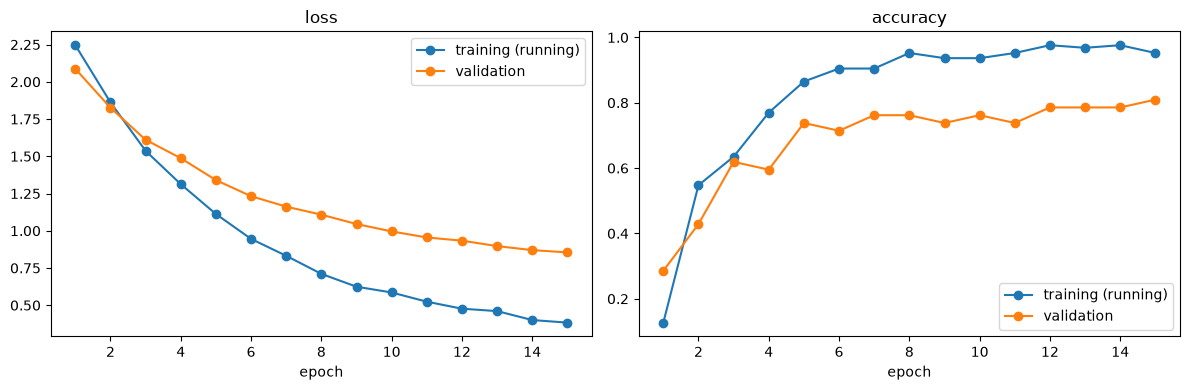

In [11]:
criterion = nn.CrossEntropyLoss()


def evaluate(model, loader):
    """Mean loss and accuracy over a loader, in evaluation mode, without gradients."""
    model.eval()
    total_loss, correct, seen = 0.0, 0, 0
    with torch.no_grad():
        for images, targets in loader:
            logits = model(images)
            total_loss += criterion(logits, targets).item() * len(targets)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            seen += len(targets)
    return total_loss / seen, correct / seen


rows = []
torch.manual_seed(SEED)
for epoch in range(1, EPOCHS + 1):
    started = time.perf_counter()
    train_mode(model)                                   # الحل: وضع التدريب مع إبقاء BN في التقييم
    total_loss, correct, seen = 0.0, 0, 0
    for images, targets in train_loader:
        optimiser.zero_grad()                           # الحل: الأسطر الخمسة
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * len(targets)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        seen += len(targets)
    val_loss, val_accuracy = evaluate(model, val_loader)
    rows.append({"epoch": epoch, "train_loss": total_loss / seen,
                 "train_accuracy": correct / seen, "val_loss": val_loss,
                 "val_accuracy": val_accuracy,
                 "seconds": time.perf_counter() - started})
    print(f"epoch {epoch:>2}  train loss {total_loss / seen:.3f} acc {correct / seen:.3f}  |  "
          f"val loss {val_loss:.3f} acc {val_accuracy:.3f}  |  "
          f"{rows[-1]['seconds']:.1f} s")

curves = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(curves["epoch"], curves[f"train_{metric}"], marker="o", label="training (running)")
    ax.plot(curves["epoch"], curves[f"val_{metric}"], marker="o", label="validation")
    ax.set_xlabel("epoch")
    ax.set_title(metric)
    ax.legend()
plt.tight_layout()
plt.show()

### Task 2.6 — the test set, once, and the photos it got wrong

Every decision so far — the transforms, the learning rate, the number of epochs — was made looking at
the validation set. The test set has not been touched. Score it **once**.

Then three things:

- **Compare against the baseline.** Always guessing the commonest species scores 0.124. A number
  means nothing until it is set next to that.
- **The confusion matrix.** 10×10, true species down the side, predicted across the top. With about
  four test photos per species, a single mistake is a quarter of that species — read the matrix as a
  list of individual mistakes, not as rates.
- **Look at the mistakes.** The cell shows every misclassified test photo with its true and predicted
  species. Before you blame the model, ask whether you could tell those two apart at 128×128.

Then write one sentence in `FINDING`: what accuracy you got against the baseline, and what the
mistakes have in common.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — مجموعة الاختبار مرّة واحدة، والصور التي أخطأ فيها

كل قرار حتى الآن — التحويلات، ومعدّل التعلّم، وعدد الحقب — اتُّخذ بالنظر إلى مجموعة التحقّق. ولم تُمسّ مجموعة
الاختبار. فقيّمها **مرّة واحدة**.

ثم ثلاثة أشياء:

- **قارن بخطّ الأساس.** تخمين النوع الأشيع دائمًا يبلغ ٠٫١٢٤. والرقم لا يعني شيئًا حتى يُوضع إلى جانب ذلك.
- **مصفوفة الالتباس.** ١٠×١٠، النوع الحقيقي على الجانب والمتوقَّع في الأعلى. ومع نحو أربع صور اختبار لكل
  نوع، يكون الخطأ الواحد ربع ذلك النوع — فاقرأ المصفوفة قائمةَ أخطاء فردية لا نِسَبًا.
- **انظر إلى الأخطاء.** تعرض الخلية كل صورة اختبار صُنّفت خطأً مع نوعها الحقيقي والمتوقَّع. وقبل أن تلوم
  النموذج، اسأل نفسك هل كنت ستُميّز بين هذين عند ١٢٨×١٢٨.

ثم اكتب جملة واحدة في `FINDING`: ما الدقّة التي حصلت عليها مقابل خطّ الأساس، وما الذي يجمع بين الأخطاء.

</div>

test accuracy 0.905 on 42 photos — 38 right — against a baseline of 0.124


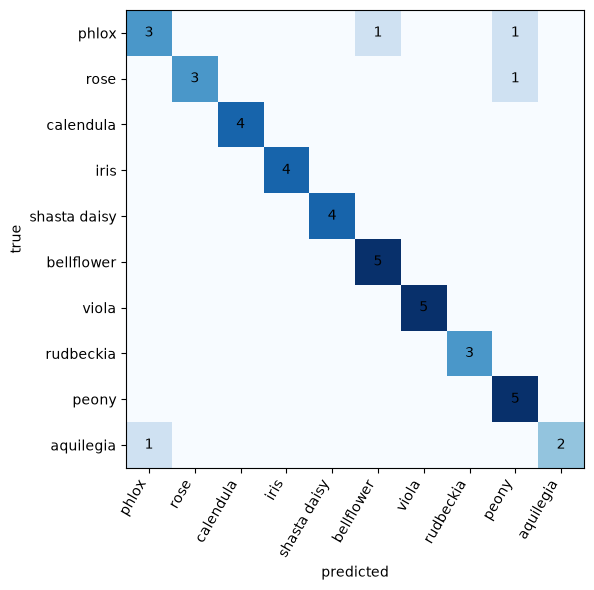

4 mistakes:


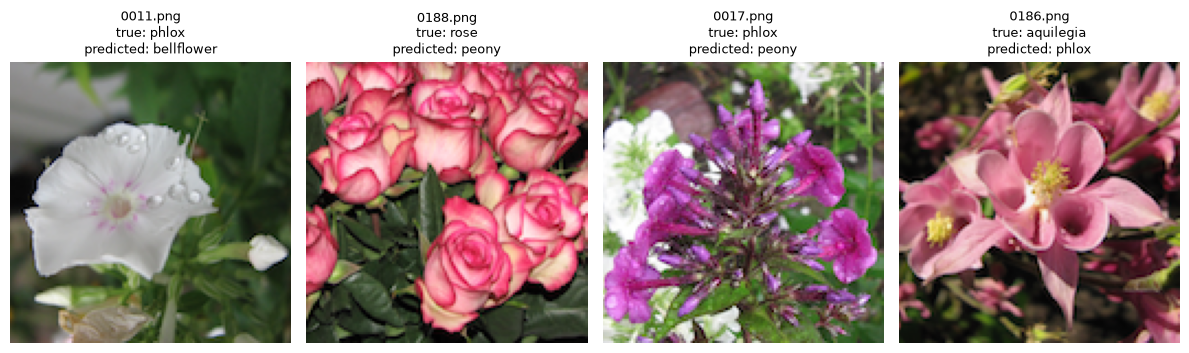


The frozen ResNet-18 head scored 0.905 on the test set against a majority-class baseline of 0.124; the 4 mistakes were: phlox read as bellflower; rose read as peony; phlox read as peony; aquilegia read as phlox — edit this to say what they share (similar colour or shape at 128x128?).


In [12]:
# الحل: النداء الوحيد على مجموعة الاختبار
_, FINAL_ACCURACY = evaluate(model, test_loader)

# الحل: التنبّؤات بترتيب test_df
model.eval()
with torch.no_grad():
    TEST_PRED = torch.cat([model(images).argmax(dim=1) for images, _ in test_loader]).numpy()

TEST_TRUE = test_df["label"].to_numpy()
BASELINE = counts.max() / len(labels)
print(f"test accuracy {FINAL_ACCURACY:.3f} on {len(TEST_TRUE)} photos — "
      f"{int(round(FINAL_ACCURACY * len(TEST_TRUE)))} right — against a baseline of {BASELINE:.3f}")

confusion = confusion_matrix(TEST_TRUE, TEST_PRED, labels=range(len(FLOWER_NAMES)))
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(confusion, cmap="Blues")
ax.set_xticks(range(10), FLOWER_NAMES, rotation=60, ha="right")
ax.set_yticks(range(10), FLOWER_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(10):
    for j in range(10):
        if confusion[i, j]:
            ax.text(j, i, confusion[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

wrong = np.flatnonzero(TEST_PRED != TEST_TRUE)
print(f"{len(wrong)} mistakes:")
if len(wrong):
    fig, axes = plt.subplots(1, len(wrong), figsize=(3 * len(wrong), 3.4), squeeze=False)
    for ax, k in zip(axes[0], wrong):
        file = test_df.iloc[k]["file"]
        ax.imshow(Image.open(IMAGE_DIR / file))
        ax.set_title(f"{file}\ntrue: {FLOWER_NAMES[TEST_TRUE[k]]}\n"
                     f"predicted: {FLOWER_NAMES[TEST_PRED[k]]}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# الحل: جملة FINDING (تُبنى تلقائيًا، عدّل آخرها بعد رؤية صور الأخطاء)
_pairs = "; ".join(f"{FLOWER_NAMES[TEST_TRUE[k]]} read as {FLOWER_NAMES[TEST_PRED[k]]}"
                   for k in wrong)
FINDING = (f"The frozen ResNet-18 head scored {FINAL_ACCURACY:.3f} on the test set against a "
           f"majority-class baseline of {BASELINE:.3f}; the {len(wrong)} mistakes were: {_pairs} "
           f"— edit this to say what they share (similar colour or shape at 128x128?).")
print(f"\n{FINDING}")

## Section 3 — Stretch: twenty species, the same `Dataset` class  (≈30 min)

The same archive holds a bigger variant, `flowers/flowers/`: **603 photos of 20 species**, the ten
from today plus rhododendron, passiflora, tulip, water lily, lilium, veronica, cosmos, annual aster,
perennial aster and snowdrop. There is no CSV this time. The label is the **first two characters of
the file name**: `07_013.png` is species 7.

You do not need a new class. `FlowerDataset` only wants a table with a `file` and a `label` column,
so the whole job is to **build that table** from the file names — a list of names, and `int(name[:2])`
for each. Then repeat Section 2: split the table 60/20/20, one `FlowerDataset` per split with the same
transforms, a fresh frozen ResNet-18 with a 20-way head, 15 epochs, and the test set once.

That is the point of writing the class around a table: preparing a new dataset means building a
table, nothing more. On the machine this notebook was written on, the 20-species head scored about
0.9 on its test set.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: عشرون نوعًا، وصنف `Dataset` نفسه (نحو ٣٠ دقيقة)

يحوي الأرشيف نفسه نسخة أكبر، `flowers/flowers/`: **٦٠٣ صور لعشرين نوعًا**، الأنواع العشرة من اليوم ومعها
الرودودندرون، وزهرة الآلام، والتوليب، وزنبق الماء، والزنبق، والفيرونيكا، والكوزموس، والأستر الحولي، والأستر
المعمّر، وزهرة الثلج. ولا يوجد CSV هذه المرّة. فالتصنيف هو **أول حرفين من اسم الملف**: `07_013.png` من
النوع ٧.

ولا تحتاج إلى صنف جديد. فـ`FlowerDataset` لا تريد إلا جدولًا فيه عمودا `file` و`label`، فالعمل كله أن **تبني
ذلك الجدول** من أسماء الملفات — قائمة بالأسماء، و`int(name[:2])` لكلٍّ منها. ثم أعِد القسم الثاني: اقسم
الجدول ٦٠/٢٠/٢٠، و`FlowerDataset` لكل قسم بالتحويلات نفسها، وResNet-18 جديدة مُجمَّدة برأس لعشرين فئة، و١٥
حقبة، ومجموعة الاختبار مرّة واحدة.

وهذا مقصد كتابة الصنف حول جدول: فإعداد مجموعة بيانات جديدة يعني بناء جدول، لا أكثر. وعلى الجهاز الذي كُتب
عليه هذا الدفتر بلغ رأس العشرين نوعًا نحو ٠٫٩ على مجموعة اختباره.

</div>

In [13]:
WIDE_DIR = DATA_ROOT / "flowers" / "flowers"

# الحل: الجدول من أسماء الملفات
_names = sorted(p.name for p in WIDE_DIR.glob("*.png"))
wide = pd.DataFrame({"file": _names, "label": [int(n[:2]) for n in _names]})
N_WIDE = int(wide["label"].max()) + 1          # يصلح سواء بدأت التصنيفات من 0 أو 1
print(f"{len(wide)} photos, labels {wide['label'].min()}..{wide['label'].max()}")


def run_wide(table, image_dir, n_classes):
    tr, rest = train_test_split(table, test_size=0.4, stratify=table["label"], random_state=SEED)
    va, te = train_test_split(rest, test_size=0.5, stratify=rest["label"], random_state=SEED)
    tl = DataLoader(FlowerDataset(tr, image_dir, TRAIN_TRANSFORM), batch_size=BATCH_SIZE, shuffle=True)
    vl = DataLoader(FlowerDataset(va, image_dir, EVAL_TRANSFORM), batch_size=64)
    el = DataLoader(FlowerDataset(te, image_dir, EVAL_TRANSFORM), batch_size=64)

    torch.manual_seed(SEED)
    m = models.resnet18(weights=WEIGHTS)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    opt = torch.optim.Adam(m.fc.parameters(), lr=LEARNING_RATE)

    for epoch in range(1, EPOCHS + 1):
        train_mode(m)
        for images, targets in tl:
            opt.zero_grad()
            loss = criterion(m(images), targets)
            loss.backward()
            opt.step()
        _, v_acc = evaluate(m, vl)
        print(f"epoch {epoch:>2}  val acc {v_acc:.3f}")
    return m, evaluate(m, el)[1]               # الاختبار مرّة واحدة


wide_model, wide_acc = run_wide(wide, WIDE_DIR, N_WIDE)
print(f"{N_WIDE}-species test accuracy: {wide_acc:.3f}")

603 photos, labels 0..19
epoch  1  val acc 0.455
epoch  2  val acc 0.587
epoch  3  val acc 0.686
epoch  4  val acc 0.777
epoch  5  val acc 0.769
epoch  6  val acc 0.760
epoch  7  val acc 0.802
epoch  8  val acc 0.818
epoch  9  val acc 0.826
epoch 10  val acc 0.826
epoch 11  val acc 0.835
epoch 12  val acc 0.843
epoch 13  val acc 0.835
epoch 14  val acc 0.843
epoch 15  val acc 0.843
20-species test accuracy: 0.876


## Save your artefacts

Two files. `flowers_head.pt` holds **only the head** — 5,130 numbers, about 20 KB — plus the name of
the pretrained weights it sits on and the class names. The backbone did not change, so saving its 45 MB
again would store nothing new: anyone can rebuild it from `IMAGENET1K_V1`. The sanity check does
exactly that and confirms the rebuilt model scores the same. `curves.parquet` is one row per epoch.

Note what is saved: a **state dict**, not a model object. Pickling a model pickles the class's import
path with it, and that breaks the moment the code moves.

<div dir="rtl" align="right">

## احفظ آثارك

ملفّان. `flowers_head.pt` يحفظ **الرأس وحده** — ٥٬١٣٠ عددًا، نحو ٢٠ كيلوبايت — مع اسم الأوزان المُدرَّبة
مسبقًا التي يجلس عليها وأسماء الفئات. فالعمود الفقري لم يتغيّر، وحفظ ميغابايتاته الخمسة والأربعين مرّة أخرى
لا يخزّن جديدًا: إذ يستطيع أي أحد أن يُعيد بناءه من `IMAGENET1K_V1`. ويفعل فحص السلامة ذلك بالضبط ويتأكّد
أن النموذج المُعاد بناؤه يُعطي النتيجة نفسها. و`curves.parquet` صف لكل حقبة.

ولاحظ ما يُحفظ: **قاموس حالة** لا كائن نموذج. فتخليل النموذج يُخلّل معه مسار استيراد الصنف، فينكسر لحظة
انتقال الشيفرة.

</div>

In [14]:
HEAD_PATH = ARTEFACT_DIR / "flowers_head.pt"
CURVES_PATH = ARTEFACT_DIR / "curves.parquet"

torch.save({"fc_state_dict": model.fc.state_dict(),
            "backbone": "resnet18",
            "weights": "IMAGENET1K_V1",
            "classes": FLOWER_NAMES,
            "kaggle_handle": KAGGLE_HANDLE,
            "epochs": EPOCHS,
            "seed": SEED,
            "test_accuracy": FINAL_ACCURACY}, HEAD_PATH)
curves.to_parquet(CURVES_PATH, index=False)

print(f"wrote {HEAD_PATH.name} ({HEAD_PATH.stat().st_size / 1024:.0f} KB) and "
      f"{CURVES_PATH.name} ({len(curves)} rows)")
print(curves.round(3).to_string(index=False))

wrote flowers_head.pt (22 KB) and curves.parquet (15 rows)
 epoch  train_loss  train_accuracy  val_loss  val_accuracy  seconds
     1       2.246           0.127     2.087         0.286    7.611
     2       1.862           0.548     1.826         0.429    7.037
     3       1.537           0.635     1.611         0.619    6.819
     4       1.313           0.770     1.487         0.595    7.681
     5       1.112           0.865     1.340         0.738    7.710
     6       0.945           0.905     1.232         0.714    8.201
     7       0.832           0.905     1.162         0.762    7.103
     8       0.711           0.952     1.108         0.762    6.746
     9       0.624           0.937     1.045         0.738    6.806
    10       0.586           0.937     0.996         0.762    7.097
    11       0.524           0.952     0.955         0.738    7.090
    12       0.477           0.976     0.934         0.786    7.228
    13       0.461           0.968     0.897         0.78

## Sanity check

The last check rebuilds the model from nothing — the ImageNet weights plus your saved head — and
re-scores the test set. If the backbone had drifted during training, this is where it would show.

<div dir="rtl" align="right">

## فحص سلامة

يُعيد الفحص الأخير بناء النموذج من لا شيء — أوزان ImageNet مع رأسك المحفوظ — ويُعيد تقييم مجموعة
الاختبار. فلو انجرف العمود الفقري أثناء التدريب لظهر ذلك هنا.

</div>

In [15]:
check(len(dataset) == 210 and sorted(set(DATASET_LABELS)) == list(range(10)),
      f"FlowerDataset must hold 210 photos in 10 classes — got {len(dataset)} photos, "
      f"classes {sorted(set(DATASET_LABELS))}",
      f"يجب أن يحوي `FlowerDataset` ٢١٠ صور في ١٠ فئات — والناتج {len(dataset)} صورة، "
      f"والفئات {sorted(set(DATASET_LABELS))}")

check(DATASET_LABELS == labels["label"].tolist(),
      "FlowerDataset must return the table's label for every row, in the table's order",
      "يجب أن يُرجع `FlowerDataset` تصنيف الجدول لكل صف، بترتيب الجدول")

sample, sample_label = FlowerDataset(labels, IMAGE_DIR, EVAL_TRANSFORM)[0]
check(isinstance(sample, torch.Tensor) and tuple(sample.shape) == (3, 224, 224)
      and isinstance(sample_label, int),
      f"with EVAL_TRANSFORM an item must be a (3, 224, 224) tensor and an int label — got "
      f"{type(sample).__name__} {tuple(getattr(sample, 'shape', ()))} and {type(sample_label).__name__}",
      f"مع `EVAL_TRANSFORM` يجب أن يكون العنصر موتّرًا (3, 224, 224) وتصنيفًا `int` — والناتج "
      f"{type(sample).__name__} {tuple(getattr(sample, 'shape', ()))} و{type(sample_label).__name__}")

split = [set(table["file"]) for table in (train_df, val_df, test_df)]
check(set().union(*split) == set(labels["file"]) and sum(map(len, split)) == len(labels),
      "the three splits must cover every photo exactly once",
      "يجب أن تغطّي التقسيمات الثلاثة كل صورة مرّة واحدة بالضبط")

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone_frozen = all(not p.requires_grad for name, p in model.named_parameters()
                      if not name.startswith("fc."))
check(trainable_now == 5130 and backbone_frozen,
      f"only the new head should train: 5,130 parameters — got {trainable_now:,}, "
      f"backbone frozen: {backbone_frozen}",
      f"يجب ألّا يتدرّب إلا الرأس الجديد: ٥٬١٣٠ معاملًا — والناتج {trainable_now:,}، "
      f"والعمود الفقري مُجمَّد: {backbone_frozen}")

check(torch.equal(model.conv1.weight, CONV1_BEFORE) and torch.equal(model.bn1.running_mean, BN1_MEAN_BEFORE),
      "the backbone must come out of training unchanged — conv1's weights or bn1's running mean "
      "moved. Calling model.train() instead of train_mode(model) is the usual cause",
      "يجب أن يخرج العمود الفقري من التدريب بلا تغيير — تحرّكت أوزان `conv1` أو المتوسّط المتحرّك لـ`bn1`. "
      "والسبب المعتاد نداء `model.train()` بدل `train_mode(model)`")

check(len(curves) == EPOCHS and curves["epoch"].tolist() == list(range(1, EPOCHS + 1)),
      f"curves needs exactly one row per epoch — got {len(curves)} rows",
      f"يحتاج `curves` صفًّا لكل حقبة بالضبط — والموجود {len(curves)} صفًّا")

check(FINAL_ACCURACY >= 0.75,
      f"a frozen ResNet-18 head should reach 0.75 test accuracy here (baseline 0.124) — "
      f"got {FINAL_ACCURACY:.3f}",
      f"يجب أن يبلغ رأس ResNet-18 المُجمَّدة دقّة اختبار ٠٫٧٥ هنا (خطّ الأساس ٠٫١٢٤) — "
      f"والناتج {FINAL_ACCURACY:.3f}")

saved = torch.load(HEAD_PATH, weights_only=True)
rebuilt = models.resnet18(weights=WEIGHTS)
rebuilt.fc = nn.Linear(rebuilt.fc.in_features, len(saved["classes"]))
rebuilt.fc.load_state_dict(saved["fc_state_dict"])
_, rebuilt_accuracy = evaluate(rebuilt, test_loader)
check(rebuilt_accuracy == FINAL_ACCURACY,
      f"ImageNet weights + the saved head must reproduce the test accuracy exactly — saved "
      f"{FINAL_ACCURACY:.4f}, rebuilt {rebuilt_accuracy:.4f}",
      f"يجب أن تُعيد أوزان ImageNet مع الرأس المحفوظ دقّة الاختبار نفسها تمامًا — المحفوظ "
      f"{FINAL_ACCURACY:.4f} والمُعاد بناؤه {rebuilt_accuracy:.4f}")

check(len(str(FINDING).split()) >= 12,
      f"task 2.6 wants a sentence, not a placeholder — got {len(str(FINDING).split())} words",
      f"تريد المهمة ٢٫٦ جملة لا عبارة نائبة — والموجود {len(str(FINDING).split())} كلمة")

report()

──────────────────────────────────────────────────────────────────
  ✓  FlowerDataset must hold 210 photos in 10 classes — got 210 photos, classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  ✓  FlowerDataset must return the table's label for every row, in the table's order
  ✓  with EVAL_TRANSFORM an item must be a (3, 224, 224) tensor and an int label — got Tensor (3, 224, 224) and int
  ✓  the three splits must cover every photo exactly once
  ✓  only the new head should train: 5,130 parameters — got 5,130, backbone frozen: True
  ✓  the backbone must come out of training unchanged — conv1's weights or bn1's running mean moved. Calling model.train() instead of train_mode(model) is the usual cause
  ✓  curves needs exactly one row per epoch — got 15 rows
  ✓  a frozen ResNet-18 head should reach 0.75 test accuracy here (baseline 0.124) — got 0.905
  ✓  ImageNet weights + the saved head must reproduce the test accuracy exactly — saved 0.9048, rebuilt 0.9048
  ✓  task 2.6 wants a sentence, not a p

## What's next

**W4D3 — Detection with YOLO.** Today's model answered "which of ten species is this photo". Tomorrow's
answers "what is in this photo, and where" — a list of boxes whose length it decides for itself. It
is also a pretrained network you did not train, and you will score it the way you scored today's:
against ground truth, with the failures on screen.

And **D5** comes back to today's question at full depth: the same ResNet-18 on 400 photos, frozen
against partly unfrozen against trained from scratch, all on one figure.

<div dir="rtl" align="right">

## ما التالي

**الأسبوع ٤ اليوم ٣ — الكشف بـYOLO.** أجاب نموذج اليوم عن «أيّ الأنواع العشرة هذه الصورة». ويُجيب نموذج الغد
عن «ماذا في هذه الصورة وأين» — قائمة صناديق يقرّر هو طولها. وهو أيضًا شبكة مُدرَّبة مسبقًا لم تُدرّبها أنت،
وستُقيّمه كما قيّمت نموذج اليوم: مقابل المرجع، والإخفاقات على الشاشة.

ويعود **اليوم الخامس** إلى سؤال اليوم بعمقه الكامل: ResNet-18 نفسها على ٤٠٠ صورة، مُجمَّدةً مقابل مفكوكة جزئيًا
مقابل مُدرَّبة من الصفر، وكلها في شكل واحد.

</div>